<a href="https://colab.research.google.com/github/paul195samudra/Fraud-Detection-In-Bank-Transaction/blob/main/Fraud_Detection(Clustering_%26_Anomaly_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/bank_transactions_data_2.csv')
print("Shape of the dataset:", df.shape)
display(df.head())

Shape of the dataset: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
numerical_stats = df.describe()

styled_stats = numerical_stats.style.background_gradient(cmap='YlOrBr')
display(styled_stats)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


**Categorical statistics**

In [ ]:
categorical_stats = df.describe(include='object').T
cmap = cm.get_cmap('YlOrBr')
background_color = cm.colors.rgb2hex(cmap(0.85))
categorical_stats = categorical_stats.style.set_properties(**{'background-color': background_color})


display(categorical_stats)

,count,unique,top,freq
TransactionID,2512,2512,TX002496,1
AccountID,2512,495,AC00460,12
TransactionDate,2512,2512,2023-04-03 16:07:53,1
TransactionType,2512,2,Debit,1944
Location,2512,43,Fort Worth,70
DeviceID,2512,681,D000548,9
IP Address,2512,592,200.136.146.93,13
MerchantID,2512,100,M026,45
Channel,2512,3,Branch,868
CustomerOccupation,2512,4,Student,657


In [ ]:
print(f'\nMissing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum()}')


Missing values: 0
Duplicated values: 0


In [ ]:
df.nunique()

,0
TransactionID,2512
AccountID,495
TransactionAmount,2455
TransactionDate,2512
TransactionType,2
Location,43
DeviceID,681
IP Address,592
MerchantID,100
Channel,3


In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
Categorical Columns: ['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']


In [ ]:
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: TransactionID
Unique Values: ['TX000001' 'TX000002' 'TX000003' ... 'TX002510' 'TX002511' 'TX002512']

Column: AccountID
Unique Values: ['AC00128' 'AC00455' 'AC00019' 'AC00070' 'AC00411' 'AC00393' 'AC00199'
 'AC00069' 'AC00135' 'AC00385' 'AC00150' 'AC00459' 'AC00392' 'AC00264'
 'AC00085' 'AC00270' 'AC00317' 'AC00359' 'AC00242' 'AC00285' 'AC00002'
 'AC00014' 'AC00095' 'AC00453' 'AC00241' 'AC00041' 'AC00441' 'AC00057'
 'AC00390' 'AC00313' 'AC00367' 'AC00291' 'AC00060' 'AC00365' 'AC00267'
 'AC00404' 'AC00202' 'AC00478' 'AC00405' 'AC00421' 'AC00480' 'AC00120'
 'AC00117' 'AC00011' 'AC00401' 'AC00282' 'AC00439' 'AC00296' 'AC00471'
 'AC00159' 'AC00482' 'AC00115' 'AC00055' 'AC00419' 'AC00374' 'AC00271'
 'AC00456' 'AC00143' 'AC00427' 'AC00438' 'AC00425' 'AC00325' 'AC00434'
 'AC00319' 'AC00460' 'AC00461' 'AC00395' 'AC00217' 'AC00053' 'AC00110'
 'AC00265' 'AC00239' 'AC00007' 'AC00022' 'AC00464' 'AC00406' 'AC00445'
 'AC00236' 'AC00220' 'AC00140' 'AC00098' 'AC00303' 'AC00373' 'AC00437'
 'AC

**distribution of transaction amounts across the sample population**

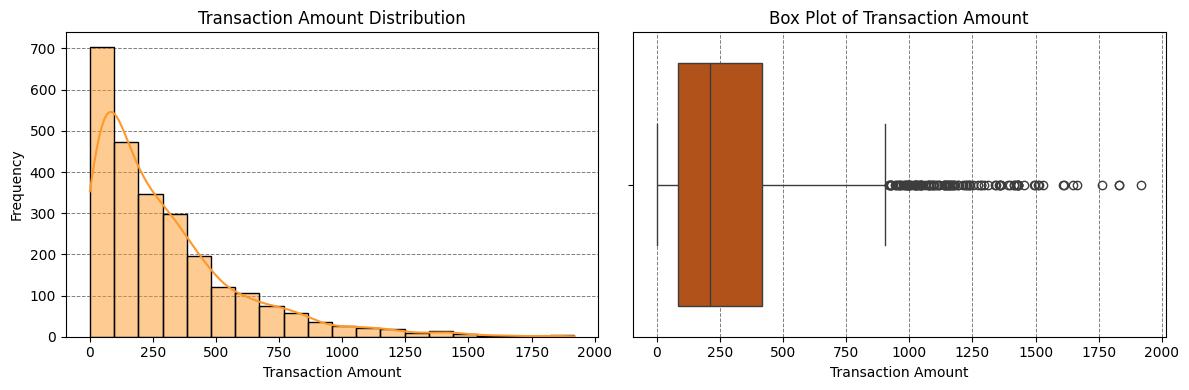


Summary Statistics for Transaction Amount:
 count    2512.000000
mean      297.593778
std       291.946243
min         0.260000
25%        81.885000
50%       211.140000
75%       414.527500
max      1919.110000
Name: TransactionAmount, dtype: float64


In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['TransactionAmount'], bins=20, kde=True, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['TransactionAmount'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Box Plot of Transaction Amount')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f'\nSummary Statistics for Transaction Amount:\n', df['TransactionAmount'].describe())

* the average age of the customers, and how much does the age vary within the customer base*

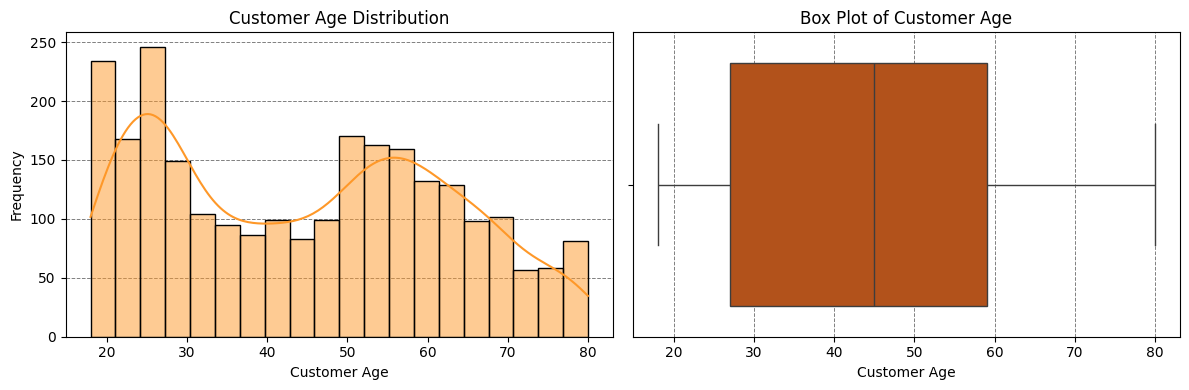


Summary Statistics for Customer Age:
 count    2512.000000
mean       44.673965
std        17.792198
min        18.000000
25%        27.000000
50%        45.000000
75%        59.000000
max        80.000000
Name: CustomerAge, dtype: float64


In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CustomerAge'], bins=20, kde=True, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Customer Age')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['CustomerAge'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Box Plot of Customer Age')
axes[1].set_xlabel('Customer Age')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f'\nSummary Statistics for Customer Age:\n', df['CustomerAge'].describe())

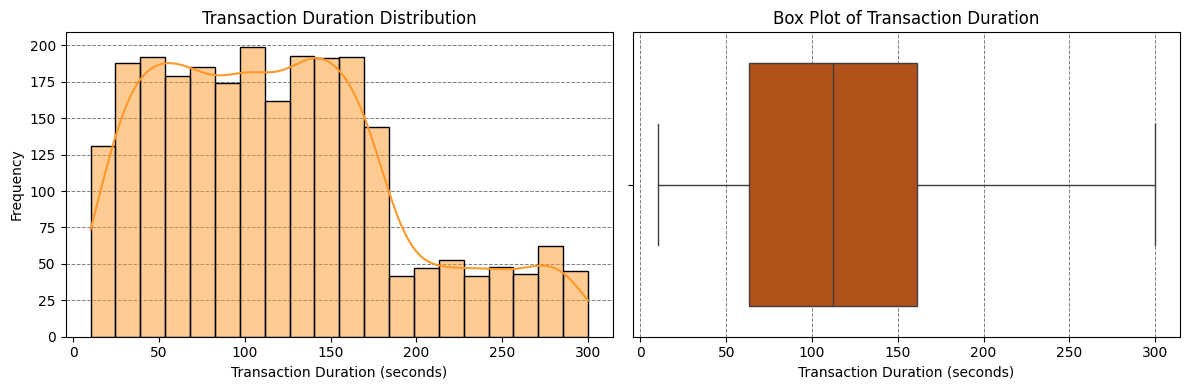


Summary Statistics for Transaction Duration:
 count    2512.000000
mean      119.643312
std        69.963757
min        10.000000
25%        63.000000
50%       112.500000
75%       161.000000
max       300.000000
Name: TransactionDuration, dtype: float64


In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['TransactionDuration'], bins=20, kde=True, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Transaction Duration Distribution')
axes[0].set_xlabel('Transaction Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['TransactionDuration'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Box Plot of Transaction Duration')
axes[1].set_xlabel('Transaction Duration (seconds)')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f'\nSummary Statistics for Transaction Duration:\n', df['TransactionDuration'].describe())

** distribution of login attempts associated with transactions**

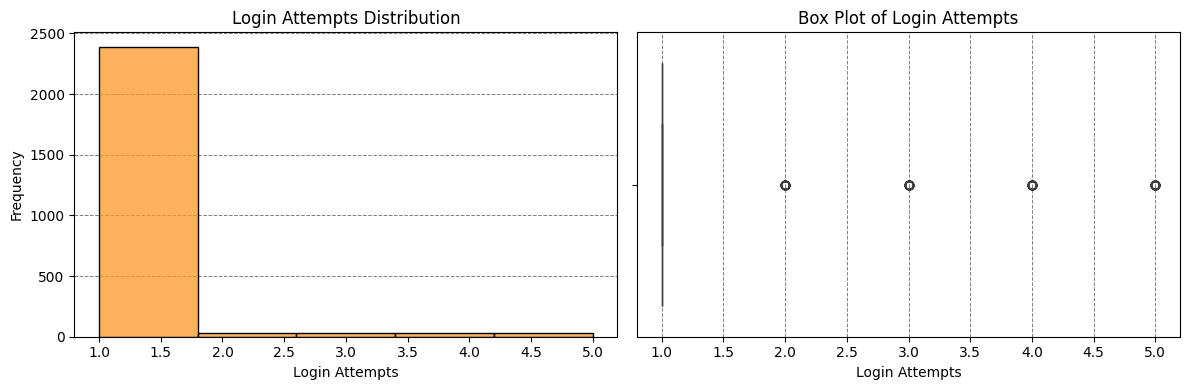


Summary Statistics for Login Attempts:
 count    2512.000000
mean        1.124602
std         0.602662
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: LoginAttempts, dtype: float64


In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['LoginAttempts'], bins=5, kde=False, color=custom_palette[1], ax=axes[0])
axes[0].set_title('Login Attempts Distribution')
axes[0].set_xlabel('Login Attempts')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['LoginAttempts'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Box Plot of Login Attempts')
axes[1].set_xlabel('Login Attempts')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f'\nSummary Statistics for Login Attempts:\n', df['LoginAttempts'].describe())

** overall distribution of account balances**

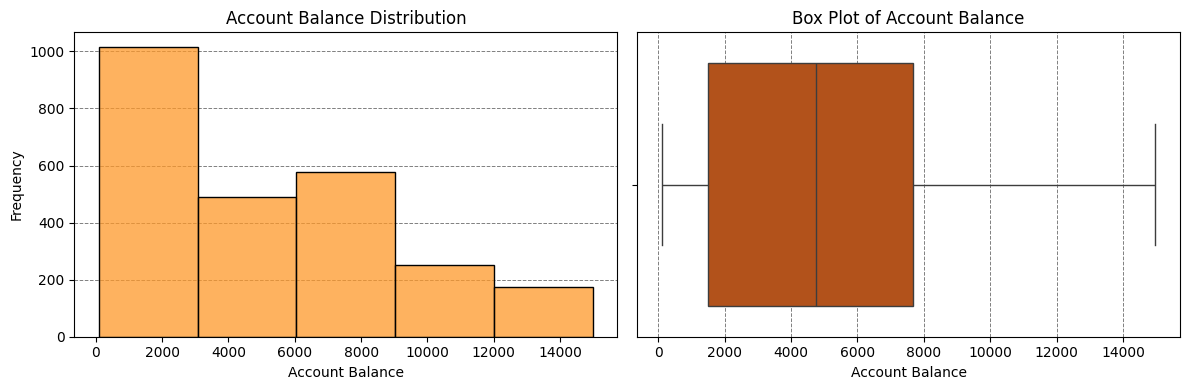


Summary Statistics for Account Balance:
 count     2512.000000
mean      5114.302966
std       3900.942499
min        101.250000
25%       1504.370000
50%       4735.510000
75%       7678.820000
max      14977.990000
Name: AccountBalance, dtype: float64


In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['AccountBalance'], bins=5, kde=False, color=custom_palette[1], ax=axes[0]) # bins adjusted to 5
axes[0].set_title('Account Balance Distribution')
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

sns.boxplot(x=df['AccountBalance'], color=custom_palette[2], ax=axes[1])
axes[1].set_title('Box Plot of Account Balance')
axes[1].set_xlabel('Account Balance')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f'\nSummary Statistics for Account Balance:\n', df['AccountBalance'].describe())

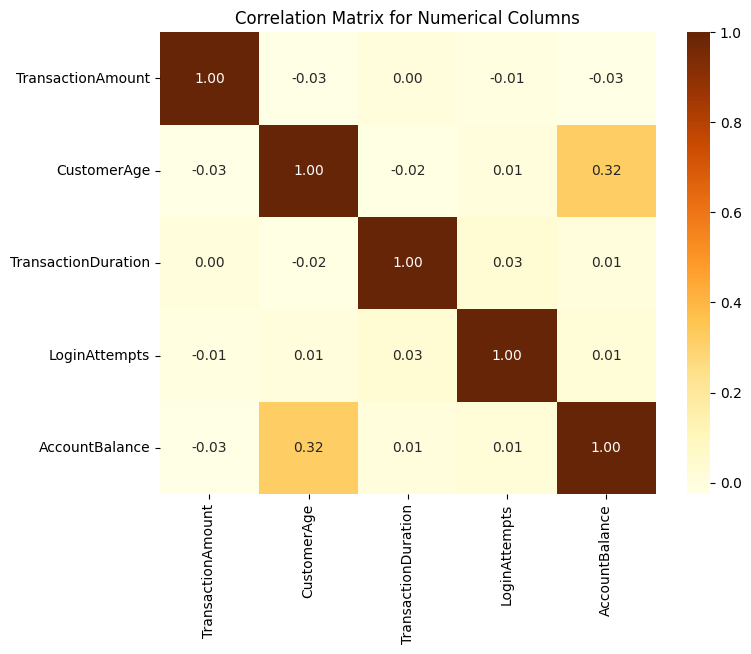

In [ ]:
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap=cmap, fmt=".2f")
plt.title('Correlation Matrix for Numerical Columns')
plt.show()

*distribution of transaction types (Credit/Debit)*

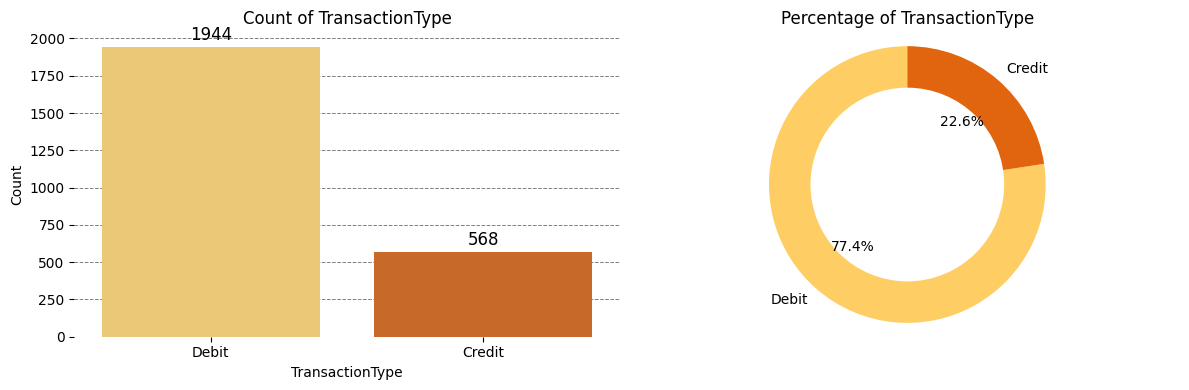

In [ ]:
def plot_categorical_distribution(df, feature, palette="YlOrBr"):
    num_categories = len(df[feature].unique())

    custom_palette = sns.color_palette(palette, num_categories)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x=feature, data=df, ax=axes[0], palette=custom_palette)
    axes[0].set_title(f'Count of {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')

    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='baseline',
                         color='black', fontsize=12,
                         xytext=(0, 5),
                         textcoords='offset points')

    axes[0].set_axisbelow(True)
    axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
    sns.despine(left=True, bottom=True)


    feature_counts = df[feature].value_counts()
    wedges, texts, autotexts = axes[1].pie(
        feature_counts,
        labels=feature_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=custom_palette
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    axes[1].set_title(f'Percentage of {feature}')
    axes[1].axis('equal')
    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df, 'TransactionType')

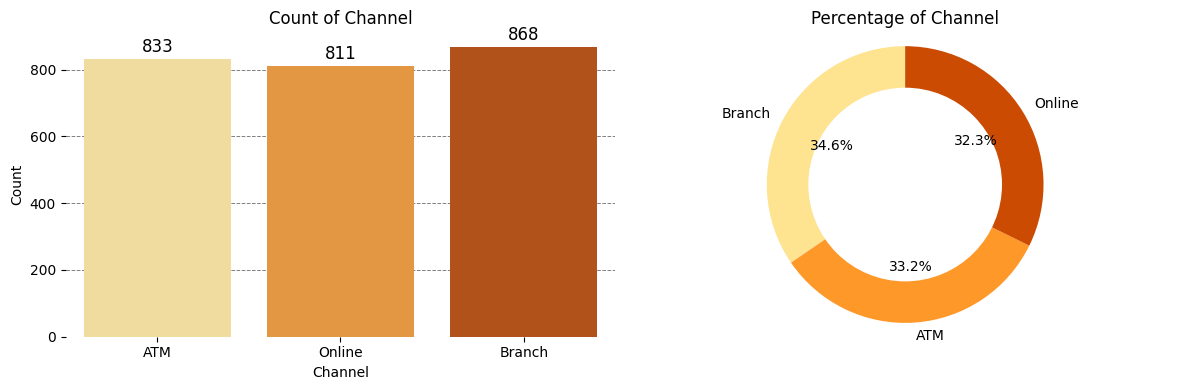

In [ ]:
plot_categorical_distribution(df, 'Channel')

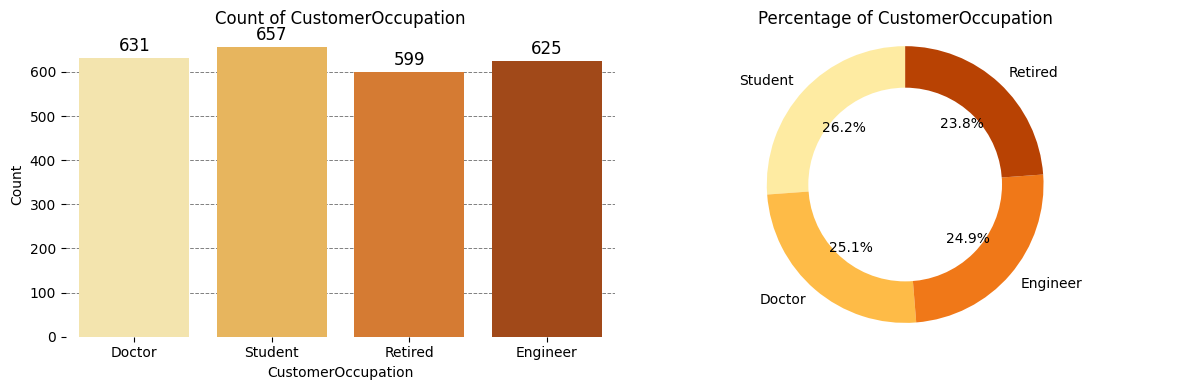

In [ ]:
plot_categorical_distribution(df, 'CustomerOccupation')

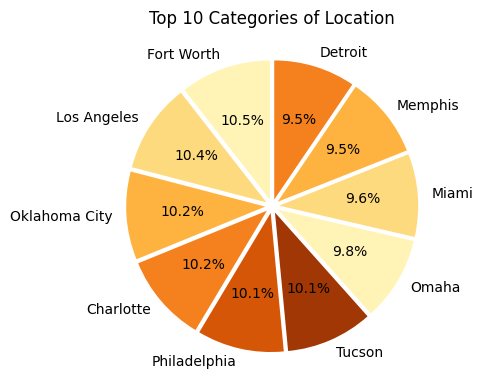

In [ ]:
def plot_top_categories_pie_chart(column_name, data=df, palette='YlOrBr'):
    plt.figure(figsize=(8, 4))

    top_categories = data[column_name].value_counts().nlargest(10)

    top_categories.plot.pie(autopct='%1.1f%%', colors=sns.color_palette(palette),
                             startangle=90, explode=[0.05] * len(top_categories))

    plt.title(f'Top 10 Categories of {column_name}')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

plot_top_categories_pie_chart('Location')

In [ ]:
location_stats = df.groupby('Location')['TransactionAmount'].agg(['count', 'mean', 'median'])
print(location_stats.nlargest(10, 'count'))

               count        mean  median
Location                                
Fort Worth        70  296.810571  240.41
Los Angeles       69  285.155797  170.19
Charlotte         68  260.039118  185.15
Oklahoma City     68  319.353529  226.50
Philadelphia      67  290.586866  177.05
Tucson            67  305.369552  214.83
Omaha             65  283.143846  178.91
Miami             64  265.144219  168.07
Detroit           63  327.139048  235.40
Houston           63  308.200794  224.19


**average transaction amount for credit transactions compared to debit transactions**

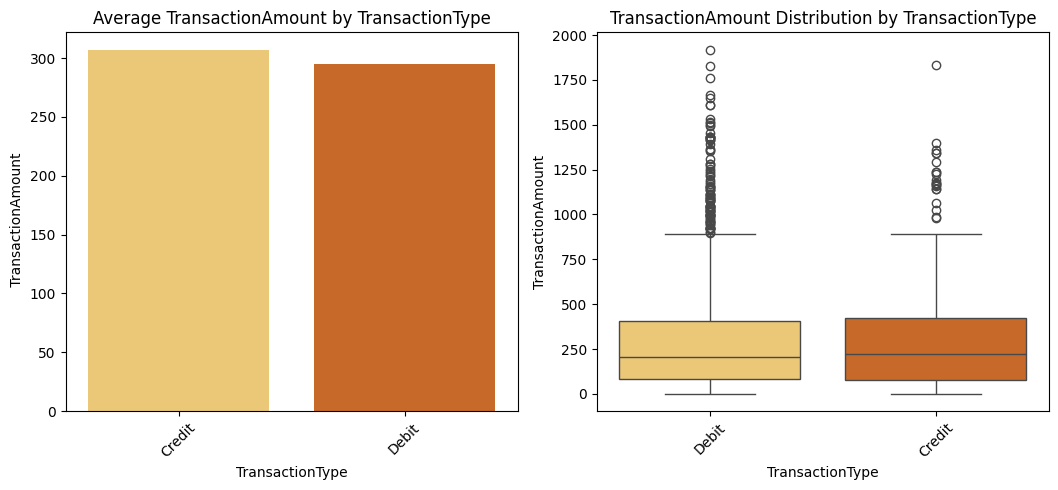

In [ ]:
def plot_categorical_relationships(column_name, data=df, palette='YlOrBr'):
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    avg_transaction = data.groupby(column_name)['TransactionAmount'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_transaction.index, y=avg_transaction.values, palette=palette)
    plt.title(f'Average TransactionAmount by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel(' TransactionAmount')
    plt.xticks(rotation=45)


    plt.subplot(1, 3, 2)
    sns.boxplot(x=column_name, y='TransactionAmount', data=data, palette=palette)
    plt.title(f'TransactionAmount Distribution by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('TransactionAmount')
    plt.xticks(rotation=45)


    plt.tight_layout()
    plt.show()

plot_categorical_relationships('TransactionType')

**average transaction amount for each transaction channel ( Online, ATM, Branch)**

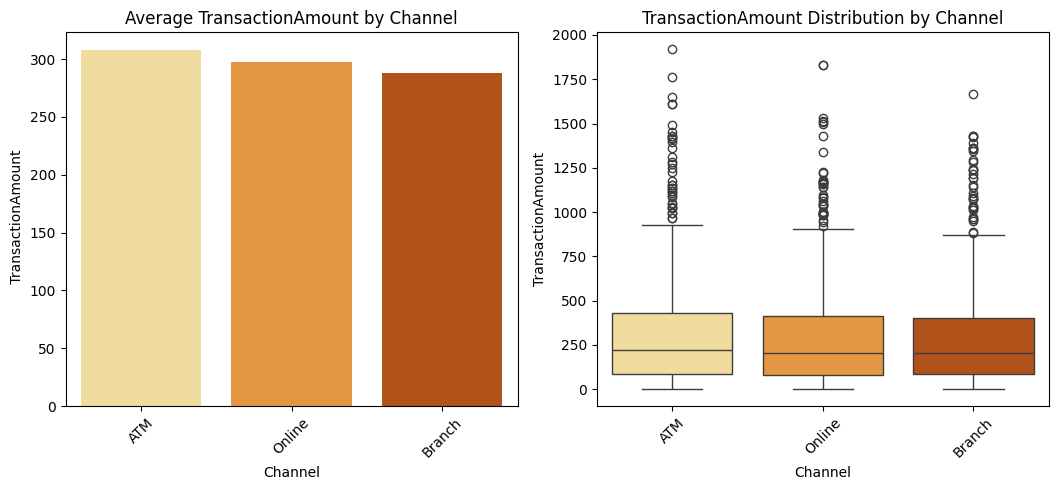

In [ ]:
plot_categorical_relationships('Channel')


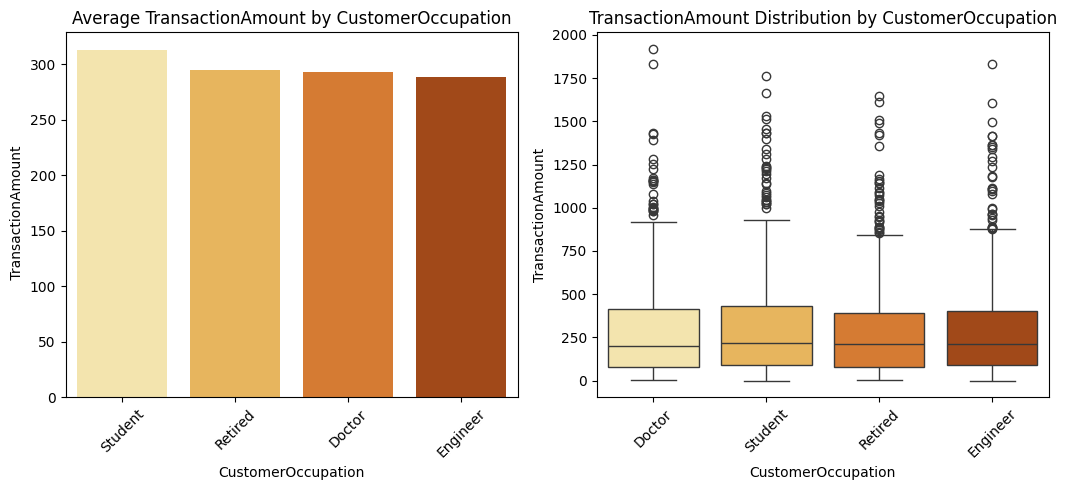

In [ ]:
plot_categorical_relationships('CustomerOccupation')

**average transaction  top 10 most frequent locations**

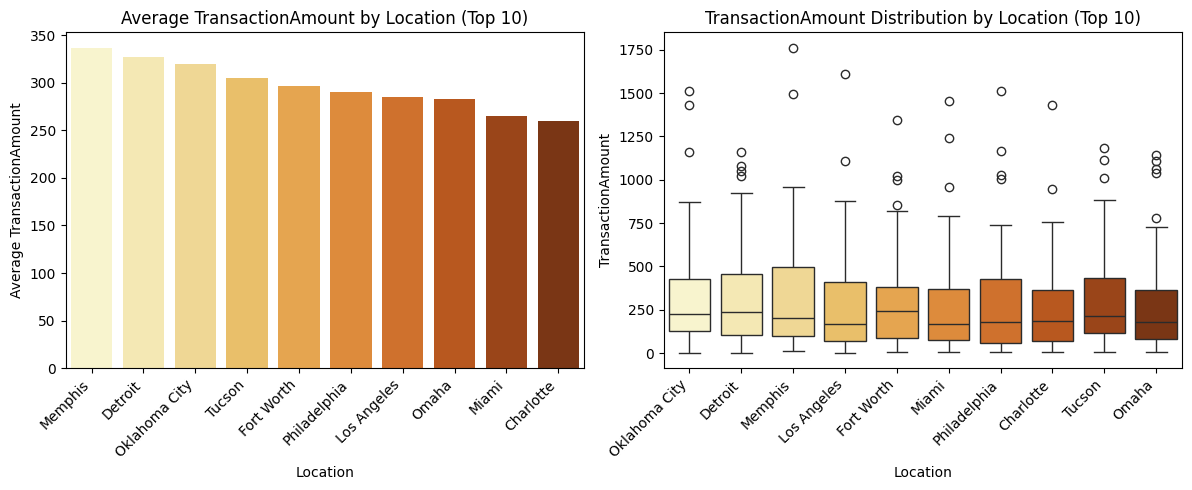

In [ ]:
def plot_categorical_relationships_improved(column_name, data=df, top_n=15, palette='YlOrBr'):
    top_categories = data[column_name].value_counts().index[:top_n]
    filtered_data = data[data[column_name].isin(top_categories)]

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    avg_transaction = filtered_data.groupby(column_name)['TransactionAmount'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_transaction.index, y=avg_transaction.values, palette=palette)
    plt.title(f'Average TransactionAmount by {column_name} (Top {top_n})')
    plt.xlabel(column_name)
    plt.ylabel('Average TransactionAmount')
    plt.xticks(rotation=45, ha='right')

    plt.subplot(1, 3, 2)
    sns.boxplot(x=column_name, y='TransactionAmount', data=filtered_data, palette=palette)
    plt.title(f'TransactionAmount Distribution by {column_name} (Top {top_n})')
    plt.xlabel(column_name)
    plt.ylabel('TransactionAmount')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

plot_categorical_relationships_improved('Location', top_n=10)

Number of high-value transactions (top 5%): 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
74,TX000075,AC00265,1212.51,2023-10-04 16:36:29,Debit,Indianapolis,D000231,193.83.0.183,M036,Branch,20,Student,24,1,605.95,2024-11-04 08:06:51
82,TX000083,AC00236,922.55,2023-01-23 16:32:48,Debit,Detroit,D000206,21.97.154.92,M004,ATM,63,Retired,87,1,4715.84,2024-11-04 08:11:07
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,Austin,D000574,165.114.224.47,M012,Online,54,Engineer,30,1,8654.28,2024-11-04 08:06:53
110,TX000111,AC00068,1045.22,2023-11-22 16:13:39,Debit,Columbus,D000400,77.7.223.184,M077,ATM,53,Retired,73,1,1829.90,2024-11-04 08:07:35
129,TX000130,AC00320,1036.66,2023-07-11 16:39:53,Debit,San Antonio,D000015,53.218.177.171,M062,Branch,58,Doctor,144,1,5541.57,2024-11-04 08:09:24


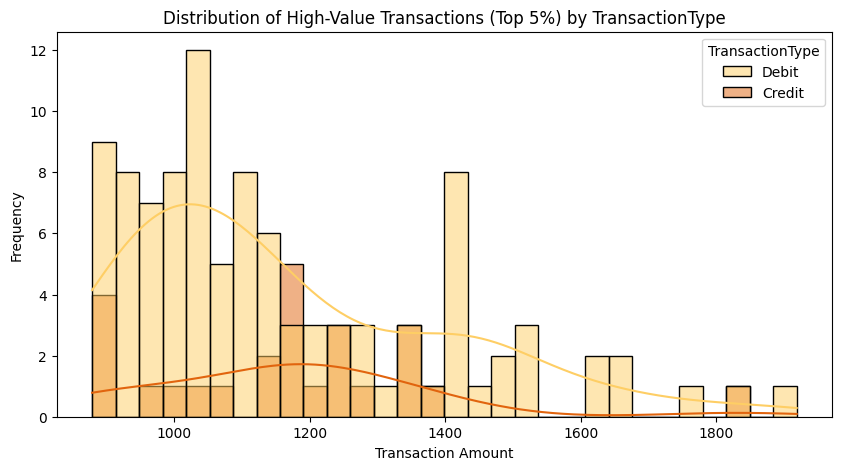

In [ ]:
high_value_threshold = df['TransactionAmount'].quantile(0.95)
high_value_transactions = df[df['TransactionAmount'] > high_value_threshold]
print(f"Number of high-value transactions (top 5%): {len(high_value_transactions)}")
display(high_value_transactions.head())

plt.figure(figsize=(10, 5))
sns.histplot(data=high_value_transactions, x='TransactionAmount', bins=30, kde=True, hue='TransactionType', palette='YlOrBr')
plt.title('Distribution of High-Value Transactions (Top 5%) by TransactionType')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

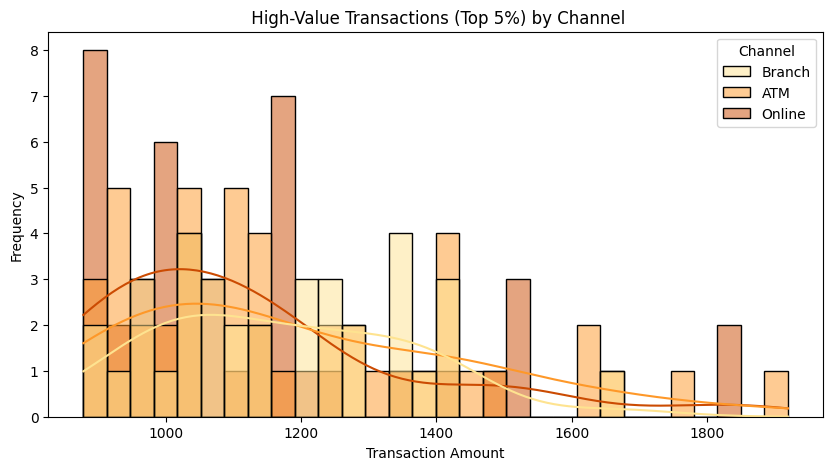

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=high_value_transactions, x='TransactionAmount', bins=30, kde=True, hue='Channel', palette='YlOrBr')
plt.title(' High-Value Transactions (Top 5%) by Channel')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

**distribution of time differences between frequent transactions**

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df_sorted = df.sort_values(by=['AccountID', 'TransactionDate'])
df_sorted['TimeDifference'] = df_sorted.groupby('AccountID')['TransactionDate'].diff().dt.total_seconds()

short_interval_threshold = 3600
frequent_transactions = df_sorted[df_sorted['TimeDifference'] <= short_interval_threshold]

print(f"Frequent transactions (within 1 hour): {len(frequent_transactions)}")
display(frequent_transactions.head())



Frequent transactions (within 1 hour): 16


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeDifference
95,TX000096,AC00010,508.68,2023-06-26 16:16:50,Credit,Mesa,D000622,193.108.17.115,M048,Branch,51,Engineer,127,1,7708.41,2024-11-04 08:09:32,505.0
1258,TX001259,AC00020,603.23,2023-08-24 17:34:13,Debit,Detroit,D000238,38.210.156.148,M017,Branch,28,Student,48,1,117.98,2024-11-04 08:08:18,2812.0
2497,TX002498,AC00030,348.17,2023-05-10 17:56:31,Debit,El Paso,D000269,82.51.236.134,M072,ATM,21,Student,181,1,1887.84,2024-11-04 08:11:06,394.0
496,TX000497,AC00114,286.50,2023-10-23 16:58:04,Credit,Boston,D000602,16.128.130.153,M097,Branch,30,Engineer,60,1,8517.95,2024-11-04 08:09:17,451.0
2341,TX002342,AC00144,97.73,2023-05-29 17:55:23,Debit,Sacramento,D000038,135.29.211.116,M018,Branch,69,Doctor,156,1,7885.21,2024-11-04 08:08:27,2480.0


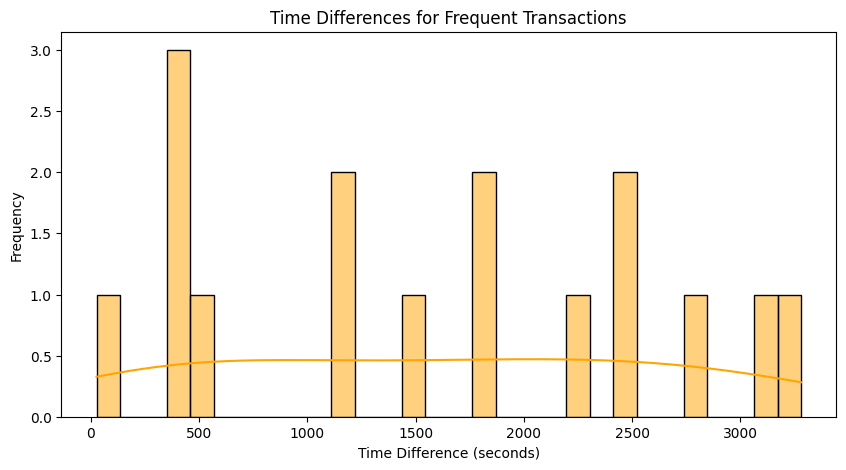

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(frequent_transactions['TimeDifference'], bins=30, kde=True, color = "orange")
plt.title('Time Differences for Frequent Transactions')
plt.xlabel('Time Difference (seconds)')
plt.ylabel('Frequency')
plt.show()

**distribution of balance changes**

Number of transactions with large balance changes: 125


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,13382.67
6,TX000007,AC00199,7.08,2023-02-15 16:36:48,Credit,Seattle,D000241,140.212.253.222,M019,ATM,37,Doctor,139,1,13316.71,2024-11-04 08:10:09,13323.79
34,TX000035,AC00365,255.26,2023-10-27 16:42:49,Credit,San Francisco,D000357,92.214.76.157,M002,Branch,45,Doctor,50,1,14815.87,2024-11-04 08:10:51,15071.13
41,TX000042,AC00480,34.02,2023-01-09 16:13:21,Debit,Philadelphia,D000627,109.105.179.186,M046,Online,38,Doctor,19,1,14214.48,2024-11-04 08:11:45,14180.46
42,TX000043,AC00120,241.42,2023-04-20 18:57:43,Credit,Charlotte,D000198,60.89.202.192,M044,Online,57,Doctor,116,1,13357.02,2024-11-04 08:09:03,13598.44


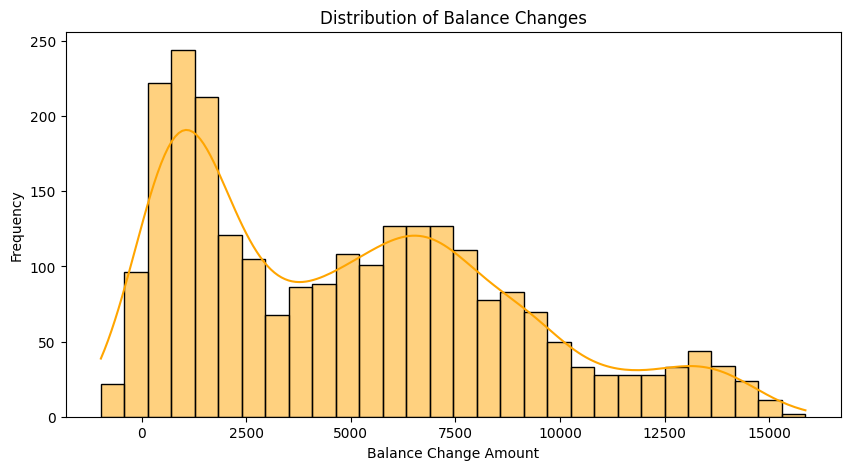

In [ ]:
df['BalanceChange'] = df.apply(
    lambda row: row['AccountBalance'] - row['TransactionAmount'] if row['TransactionType'] == 'Debit'
    else row['AccountBalance'] + row['TransactionAmount'],
    axis=1
)

balance_change_threshold = df['BalanceChange'].mean() + 2 * df['BalanceChange'].std()
large_balance_changes = df[df['BalanceChange'].abs() > balance_change_threshold]
print(f"Number of transactions with large balance changes: {len(large_balance_changes)}")
display(large_balance_changes.head())

plt.figure(figsize=(10, 5))
sns.histplot(df['BalanceChange'], bins=30, kde=True, color = "orange")
plt.title('Distribution of Balance Changes')
plt.xlabel('Balance Change Amount')
plt.ylabel('Frequency')
plt.show()

**proportion of credit vs debit transactions associated with large balance changes**

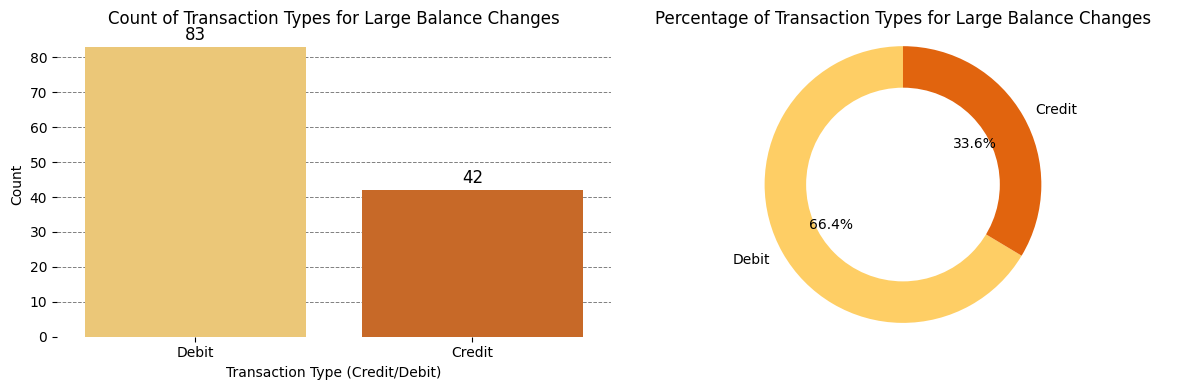

In [ ]:
transaction_type_counts = large_balance_changes['TransactionType'].value_counts()

transaction_type_percentages = large_balance_changes['TransactionType'].value_counts(normalize=True) * 100

custom_palette = sns.color_palette("YlOrBr", 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='TransactionType', data=large_balance_changes, ax=axes[0], palette=custom_palette)
axes[0].set_title('Count of Transaction Types for Large Balance Changes')
axes[0].set_xlabel('Transaction Type (Credit/Debit)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline',
                     color='black', fontsize=12,
                     xytext=(0, 5),
                     textcoords='offset points')

axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
sns.despine(left=True, bottom=True)

transaction_type_counts = large_balance_changes['TransactionType'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    transaction_type_counts,
    labels=transaction_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_palette
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
axes[1].set_title('Percentage of Transaction Types for Large Balance Changes')
axes[1].axis('equal')
plt.tight_layout()
plt.show()

**transaction channels associated with large balance changes**

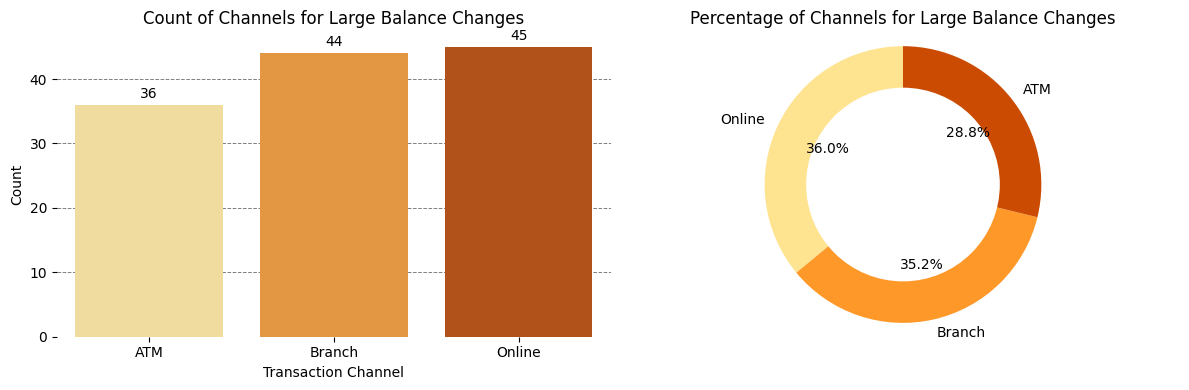

In [ ]:
channel_counts = large_balance_changes['Channel'].value_counts()

channel_percentages = large_balance_changes['Channel'].value_counts(normalize=True) * 100

custom_palette = sns.color_palette("YlOrBr", len(channel_counts.index))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Channel', data=large_balance_changes, ax=axes[0], palette=custom_palette)
axes[0].set_title('Count of Channels for Large Balance Changes')
axes[0].set_xlabel('Transaction Channel')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline',
                     color='black', fontsize=10,
                     xytext=(0, 5),
                     textcoords='offset points')

axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
sns.despine(left=True, bottom=True)

wedges, texts, autotexts = axes[1].pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_palette
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
axes[1].set_title('Percentage of Channels for Large Balance Changes')
axes[1].axis('equal')
plt.tight_layout()
plt.show()

** top 10 merchants associated with the largest number of large balance changes**

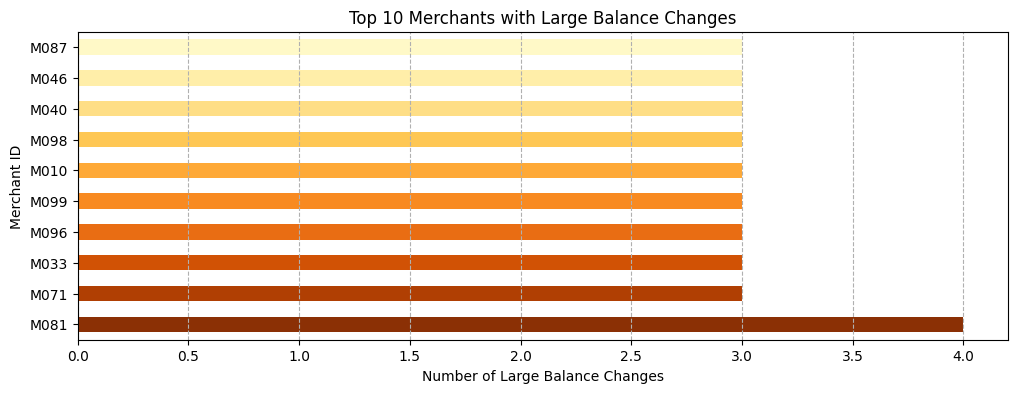

In [ ]:
merchant_counts = large_balance_changes['MerchantID'].value_counts().nlargest(10)
plt.figure(figsize=(12, 4))
merchant_counts.plot(kind='barh', color=sns.color_palette("YlOrBr_r", 10))
plt.title('Top 10 Merchants with Large Balance Changes')
plt.xlabel('Number of Large Balance Changes')
plt.ylabel('Merchant ID')
plt.grid(axis='x', linestyle='--')
plt.show()

**login attempts and the distribution of transaction amounts**

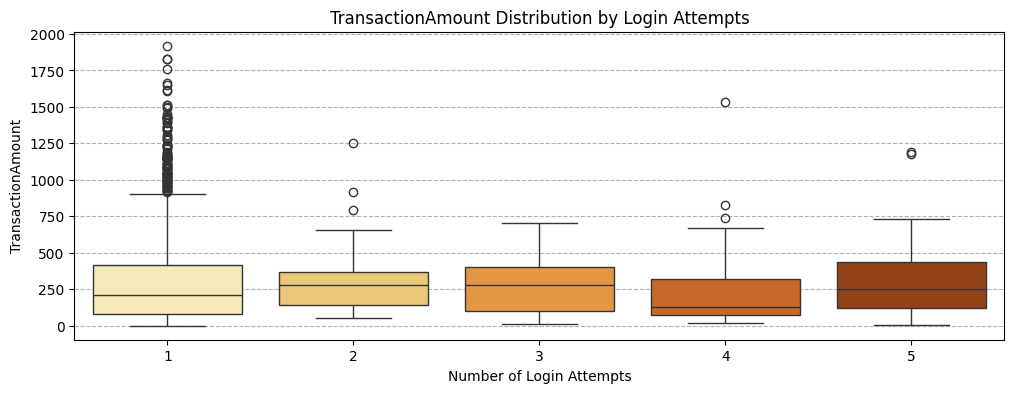

In [ ]:
plt.figure(figsize=(12, 4))
sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=df, palette='YlOrBr')
plt.title('TransactionAmount Distribution by Login Attempts')
plt.xlabel('Number of Login Attempts')
plt.ylabel('TransactionAmount')
plt.grid(axis='y', linestyle='--')
plt.show()

**login attempts for each transaction type (Credit/Debit)**

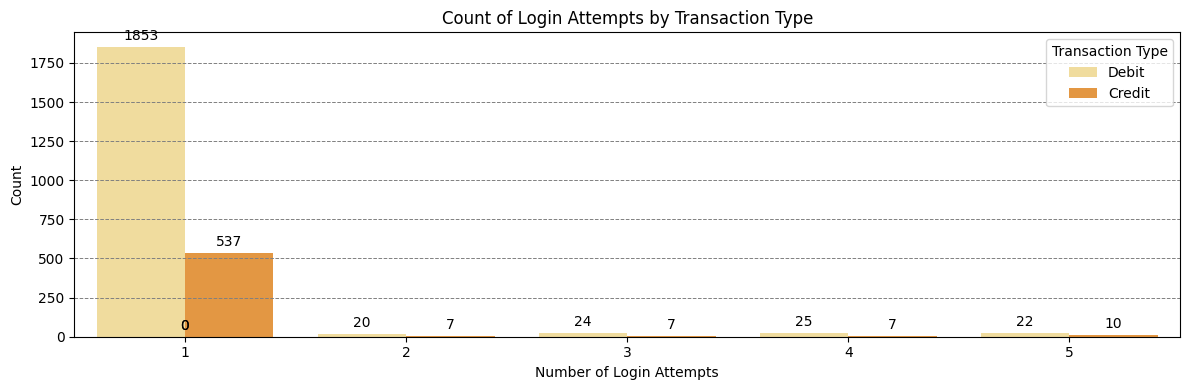

In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
plt.figure(figsize=(12, 4))
sns.countplot(x='LoginAttempts', hue='TransactionType', data=df, palette=custom_palette)
plt.title('Count of Login Attempts by Transaction Type')
plt.xlabel('Number of Login Attempts')
plt.ylabel('Count')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
plt.legend(title='Transaction Type')

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

**login attempts for each channel (Online, ATM, Branch)**

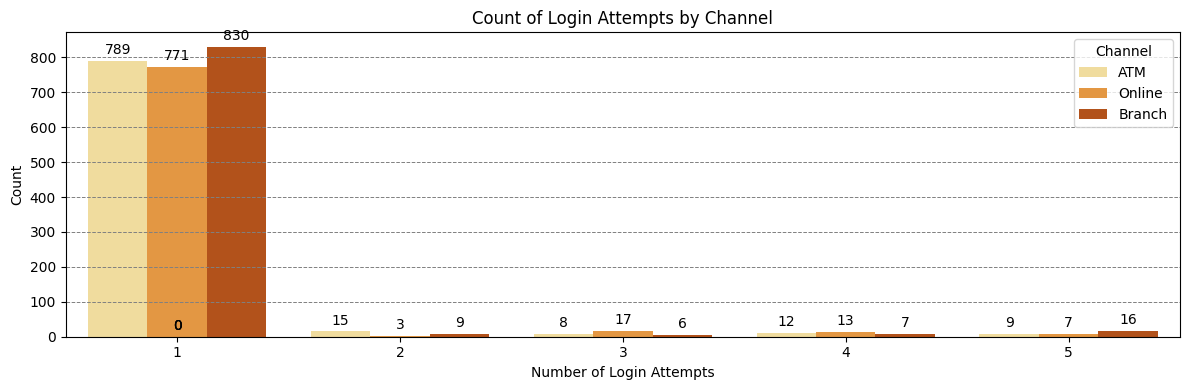

In [ ]:
custom_palette = sns.color_palette("YlOrBr", 3)
plt.figure(figsize=(12, 4))
sns.countplot(x='LoginAttempts', hue='Channel', data=df, palette=custom_palette)
plt.title('Count of Login Attempts by Channel')
plt.xlabel('Number of Login Attempts')
plt.ylabel('Count')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
plt.legend(title='Channel')

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
high_login_attempts = df[df['LoginAttempts'] > 1]
print(f"Number of transactions with more than one login attempt: {len(high_login_attempts)}")
display(high_login_attempts.head())

Number of transactions with more than one login attempt: 122


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,BalanceChange
23,TX000024,AC00453,345.84,2023-05-02 18:25:46,Debit,Fort Worth,D000162,191.82.103.198,M083,Online,22,Student,142,3,1402.50,2024-11-04 08:07:04,1056.66
26,TX000027,AC00441,246.93,2023-04-17 16:37:01,Debit,Miami,D000046,55.154.161.250,M029,ATM,23,Student,158,5,673.35,2024-11-04 08:11:38,426.42
32,TX000033,AC00060,396.45,2023-09-25 16:26:00,Debit,New York,D000621,133.67.250.163,M007,ATM,49,Engineer,168,3,9690.15,2024-11-04 08:11:13,9293.70
38,TX000039,AC00478,795.31,2023-10-12 17:07:40,Debit,Mesa,D000077,49.29.37.185,M048,ATM,66,Doctor,90,2,7914.88,2024-11-04 08:11:17,7119.57
61,TX000062,AC00002,263.99,2023-05-16 16:07:30,Debit,Dallas,D000285,7.146.35.122,M087,Branch,79,Retired,227,2,4175.02,2024-11-04 08:11:03,3911.03


** more than one login attempt**

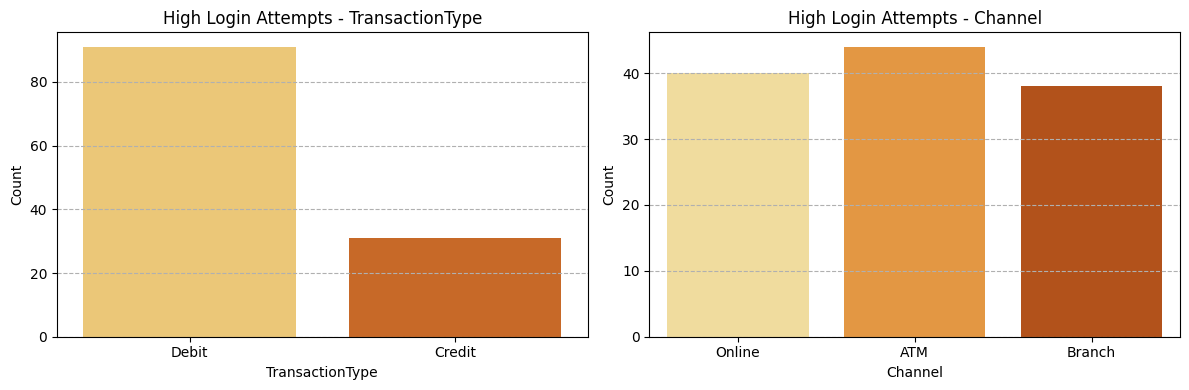

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=high_login_attempts, x='TransactionType', palette=sns.color_palette("YlOrBr", 2))
plt.title('High Login Attempts - TransactionType')
plt.xlabel('TransactionType')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--')

plt.subplot(1, 2, 2)
sns.countplot(data=high_login_attempts, x='Channel', palette=sns.color_palette("YlOrBr", len(high_login_attempts['Channel'].unique())))
plt.title('High Login Attempts - Channel')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

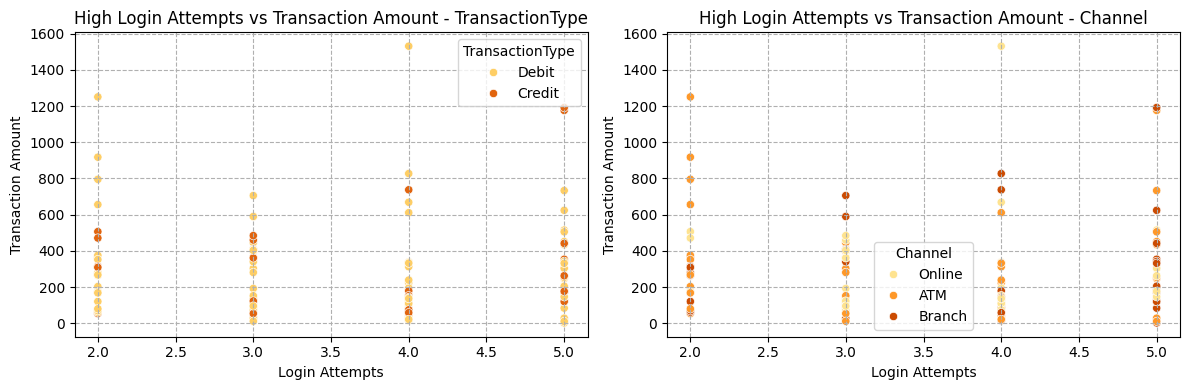

In [ ]:
high_login_attempts = df[df['LoginAttempts'] > 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=high_login_attempts, x='LoginAttempts', y='TransactionAmount', hue='TransactionType', palette="YlOrBr", ax=axes[0])
axes[0].set_title('High Login Attempts vs Transaction Amount - TransactionType')
axes[0].set_xlabel('Login Attempts')
axes[0].set_ylabel('Transaction Amount')
axes[0].grid(True, linestyle='--')

sns.scatterplot(data=high_login_attempts, x='LoginAttempts', y='TransactionAmount', hue='Channel', palette="YlOrBr", ax=axes[1])
axes[1].set_title('High Login Attempts vs Transaction Amount - Channel')
axes[1].set_xlabel('Login Attempts')
axes[1].set_ylabel('Transaction Amount')
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

** number of unique locations visited by each account**

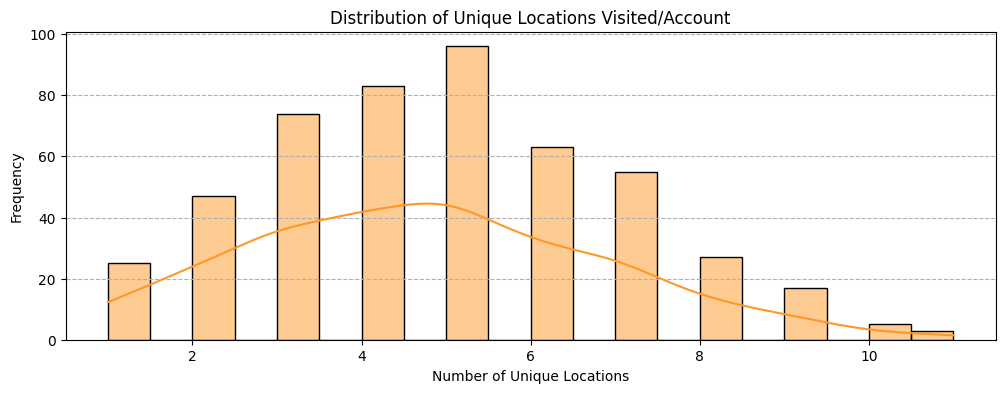

In [ ]:
location_counts_per_account = df.groupby('AccountID')['Location'].nunique().reset_index()
location_counts_per_account.columns = ['AccountID', 'UniqueLocations']

plt.figure(figsize=(12, 4))
sns.histplot(location_counts_per_account['UniqueLocations'], bins=20, kde=True, color=sns.color_palette("YlOrBr", 1)[0])
plt.title('Distribution of Unique Locations Visited/Account')
plt.xlabel('Number of Unique Locations')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--')
plt.show()

**AccountIDs of the accounts with the highest number of UniqueLocations**

In [ ]:
print(f"\nAccounts with Significant Location Shifts:")
significant_location_shifts = location_counts_per_account[location_counts_per_account['UniqueLocations'] > 4]
display(significant_location_shifts.head(10))


Accounts with Significant Location Shifts:


,AccountID,UniqueLocations
1,AC00002,7
2,AC00003,5
3,AC00004,9
4,AC00005,9
6,AC00007,5
8,AC00009,5
9,AC00010,7
10,AC00011,5
11,AC00012,6
12,AC00013,7
